## Imports & Config

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## Load Data

In [2]:
DATASET_PATH = "/kaggle/input/datasets/lostluinor/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset"
csv_path = os.path.join(DATASET_PATH, "mitotic_figures_dataset.csv")
df = pd.read_csv(csv_path)

df["label"] = df["is_atypical"].map({True: "AMF (Atypical)", False: "NMF (Normal)"})

print(f"Total samples: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
df.head()

Total samples: 19162
Columns: ['filename', 'is_atypical', 'dataset', 'split', 'is_augmented', 'augmentation_type', 'label']

Shape: (19162, 7)

Missing values:
filename                 0
is_atypical              0
dataset                  0
split                    0
is_augmented             0
augmentation_type    13938
label                    0
dtype: int64

Data types:
filename              object
is_atypical             bool
dataset               object
split                 object
is_augmented            bool
augmentation_type    float64
label                 object
dtype: object


,filename,is_atypical,dataset,split,is_augmented,augmentation_type,label
0,1371.png,False,MIDOG25,training,False,NaN,NMF (Normal)
1,TUPAC16_2232.png,False,AMI-BR,training,False,NaN,NMF (Normal)
2,3733.png,True,MIDOG25,training,False,NaN,AMF (Atypical)
3,9796.png,False,MIDOG25,training,False,NaN,NMF (Normal)
4,5477.png,False,MIDOG25,training,False,NaN,NMF (Normal)


## Value Counts

In [3]:
for col in ["is_atypical", "is_augmented", "augmentation_type"]:
    print(f"\n— {col} —")
    print(df[col].value_counts(dropna=False))


— is_atypical —
is_atypical
False    11762
True      7400
Name: count, dtype: int64

— is_augmented —
is_augmented
False    13938
True      5224
Name: count, dtype: int64

— augmentation_type —
augmentation_type
NaN    13938
1.0     1306
2.0     1306
3.0     1306
4.0     1306
Name: count, dtype: int64


## Dataset Overview

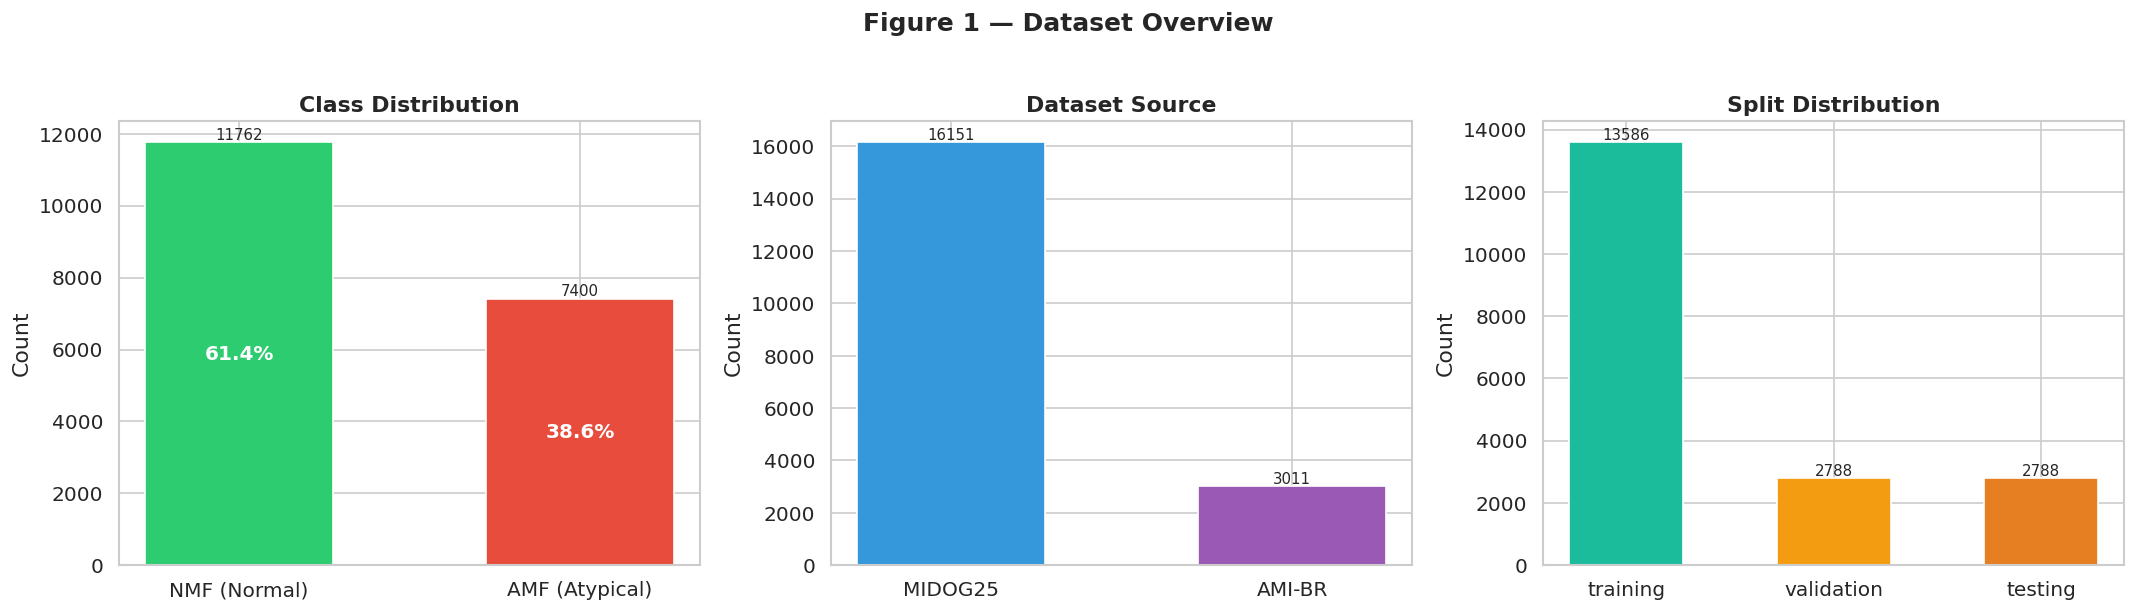

In [4]:
COLORS = {"AMF (Atypical)": "#e74c3c", "NMF (Normal)": "#2ecc71"}
SPLIT_ORDER = ["training", "validation", "testing"]

def annotate_bars(ax, fmt="{:.0f}", fontsize=9):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(fmt.format(h), (p.get_x() + p.get_width() / 2.0, h),
                        ha="center", va="bottom", fontsize=fontsize)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
ax = axes[0]
order = ["NMF (Normal)", "AMF (Atypical)"]
counts = df["label"].value_counts().reindex(order)
ax.bar(order, counts, color=[COLORS[l] for l in order], edgecolor="white", width=0.55)
annotate_bars(ax)
ax.set_title("Class Distribution", fontweight="bold")
ax.set_ylabel("Count")
pct = counts / counts.sum() * 100
for i, (cnt, p) in enumerate(zip(counts, pct)):
    ax.text(i, cnt / 2, f"{p:.1f}%", ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")

# Dataset source
ax = axes[1]
src_counts = df["dataset"].value_counts()
ax.bar(src_counts.index, src_counts.values, color=["#3498db", "#9b59b6"],
       edgecolor="white", width=0.55)
annotate_bars(ax)
ax.set_title("Dataset Source", fontweight="bold")
ax.set_ylabel("Count")

# Split distribution
ax = axes[2]
split_counts = df["split"].value_counts().reindex(SPLIT_ORDER)
ax.bar(SPLIT_ORDER, split_counts.values, color=["#1abc9c", "#f39c12", "#e67e22"],
       edgecolor="white", width=0.55)
annotate_bars(ax)
ax.set_title("Split Distribution", fontweight="bold")
ax.set_ylabel("Count")

fig.suptitle("Figure 1 — Dataset Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Augmentation Analysis

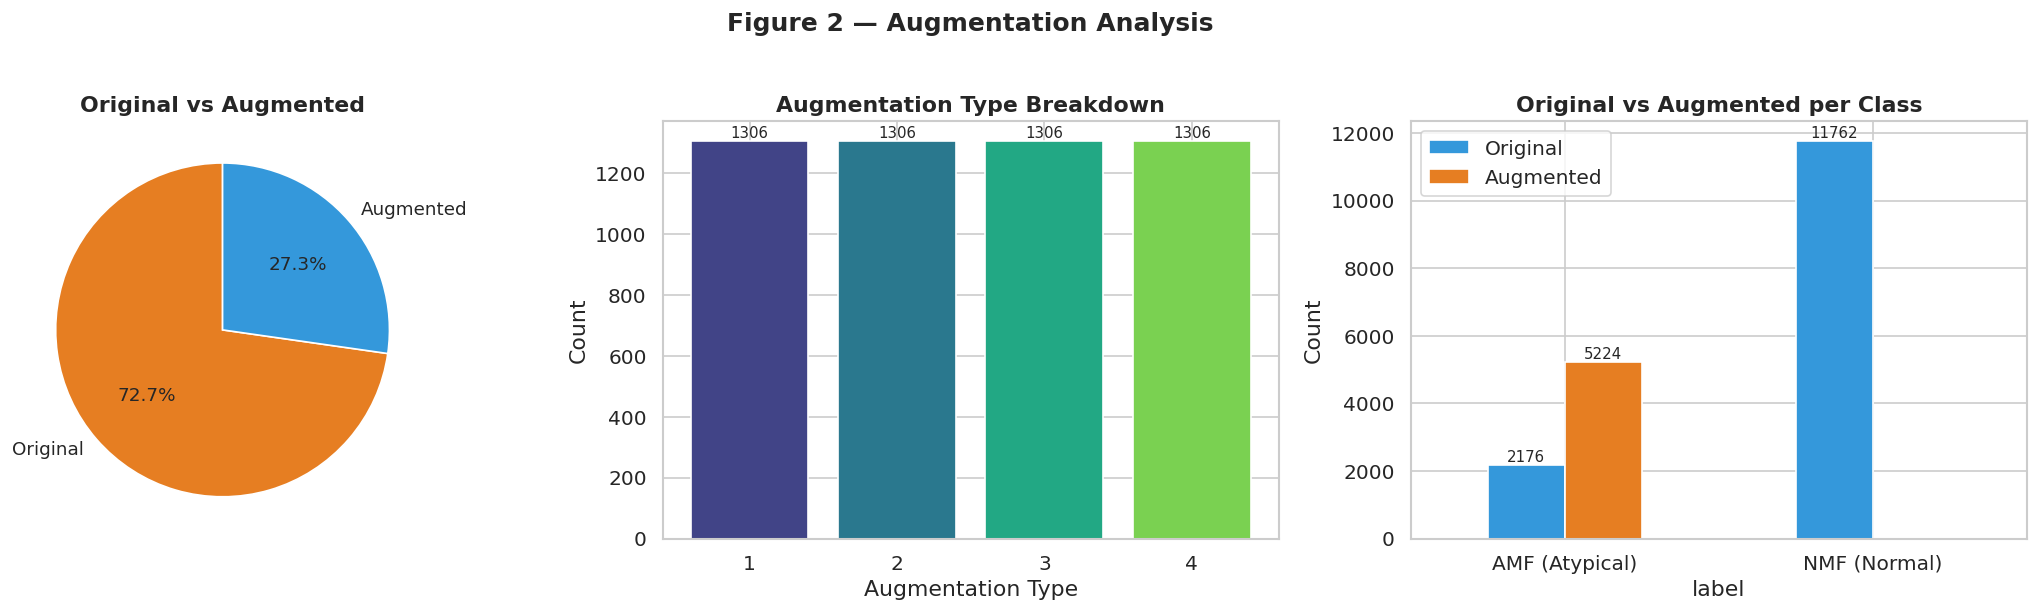

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original vs Augmented pie
ax = axes[0]
aug_counts = df["is_augmented"].value_counts().rename({True: "Augmented", False: "Original"})
ax.pie(aug_counts, labels=aug_counts.index, autopct="%1.1f%%",
       colors=["#e67e22", "#3498db"], startangle=90, textprops={"fontsize": 11})
ax.set_title("Original vs Augmented", fontweight="bold")

# Augmentation type breakdown
ax = axes[1]
aug_only = df[df["is_augmented"] == True]
aug_type_counts = aug_only["augmentation_type"].value_counts().sort_index()
ax.bar(aug_type_counts.index.astype(int).astype(str), aug_type_counts.values,
       color=sns.color_palette("viridis", len(aug_type_counts)), edgecolor="white")
annotate_bars(ax)
ax.set_title("Augmentation Type Breakdown", fontweight="bold")
ax.set_xlabel("Augmentation Type")
ax.set_ylabel("Count")

# Augmented vs Original per class
ax = axes[2]
ct = pd.crosstab(df["label"], df["is_augmented"]).rename(columns={False: "Original", True: "Augmented"})
ct.plot.bar(ax=ax, color=["#3498db", "#e67e22"], edgecolor="white", rot=0)
annotate_bars(ax)
ax.set_title("Original vs Augmented per Class", fontweight="bold")
ax.set_ylabel("Count")
ax.legend(title="")

fig.suptitle("Figure 2 — Augmentation Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Cross-Tabulation Heatmaps

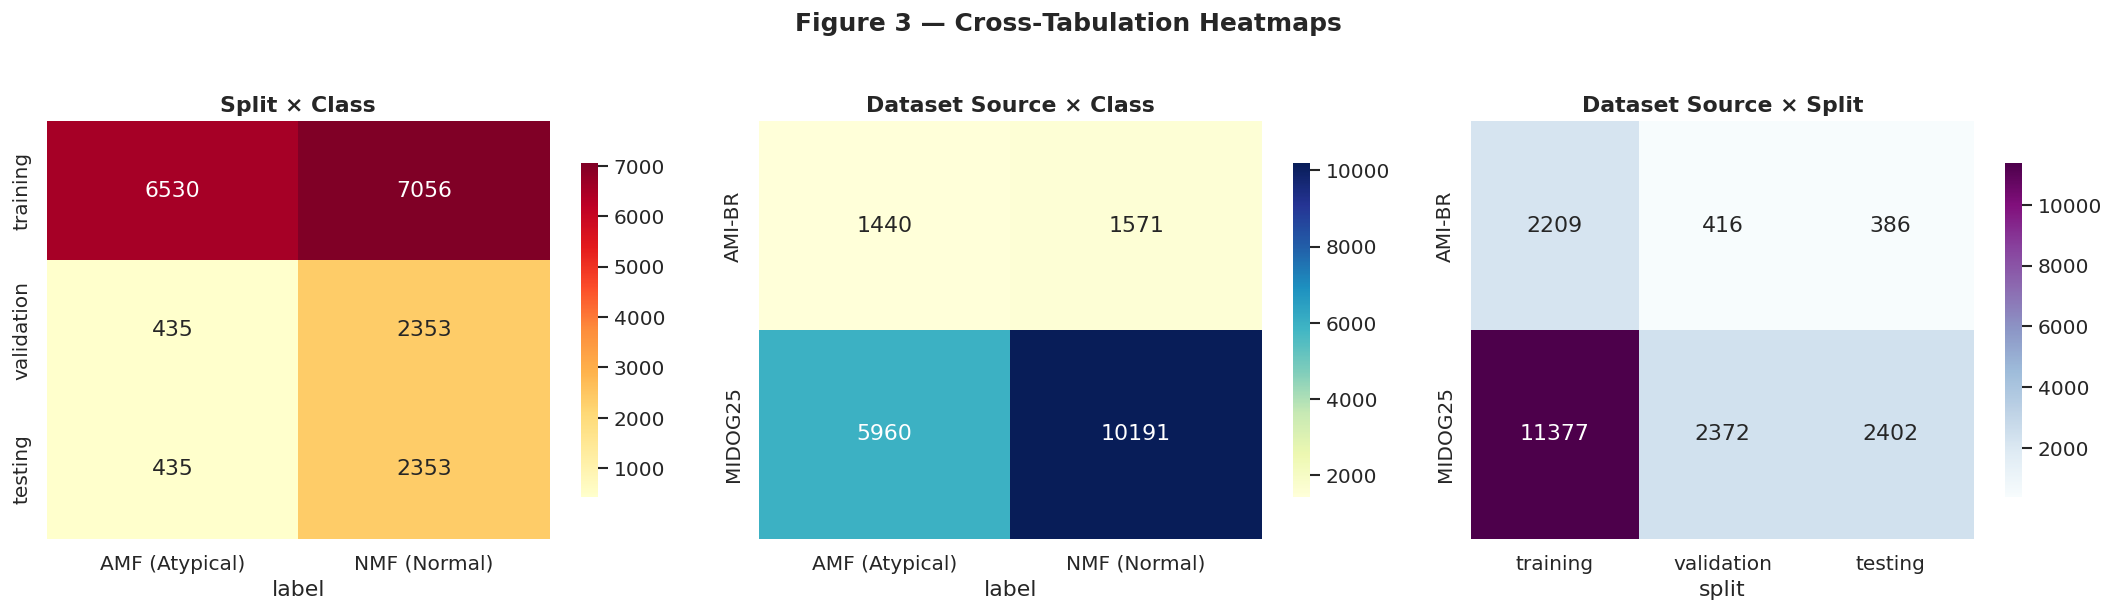

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ct1 = pd.crosstab(df["split"], df["label"]).reindex(SPLIT_ORDER)
sns.heatmap(ct1, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Split × Class", fontweight="bold")
axes[0].set_ylabel("")

ct2 = pd.crosstab(df["dataset"], df["label"])
sns.heatmap(ct2, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Dataset Source × Class", fontweight="bold")
axes[1].set_ylabel("")

ct3 = pd.crosstab(df["dataset"], df["split"]).reindex(columns=SPLIT_ORDER)
sns.heatmap(ct3, annot=True, fmt="d", cmap="BuPu", ax=axes[2], cbar_kws={"shrink": 0.8})
axes[2].set_title("Dataset Source × Split", fontweight="bold")
axes[2].set_ylabel("")

fig.suptitle("Figure 3 — Cross‑Tabulation Heatmaps", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Class Balance per Split

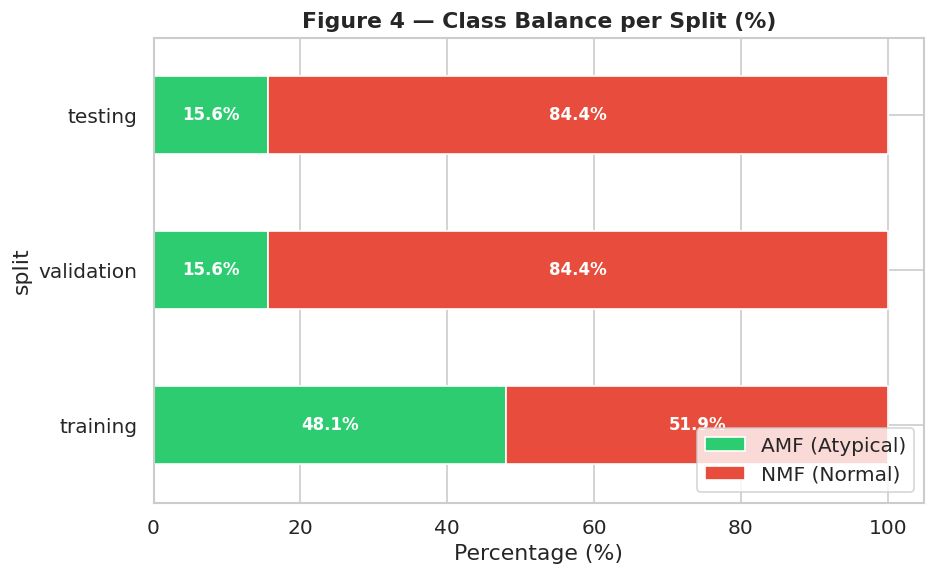

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ct_pct = pd.crosstab(df["split"], df["label"], normalize="index").reindex(SPLIT_ORDER) * 100
ct_pct.plot.barh(stacked=True, ax=ax,
                 color=[COLORS["NMF (Normal)"], COLORS["AMF (Atypical)"]],
                 edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center",
                 fontsize=10, color="white", fontweight="bold")

ax.set_xlabel("Percentage (%)")
ax.set_title("Figure 4 — Class Balance per Split (%)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Augmentation Type × Class (Training)

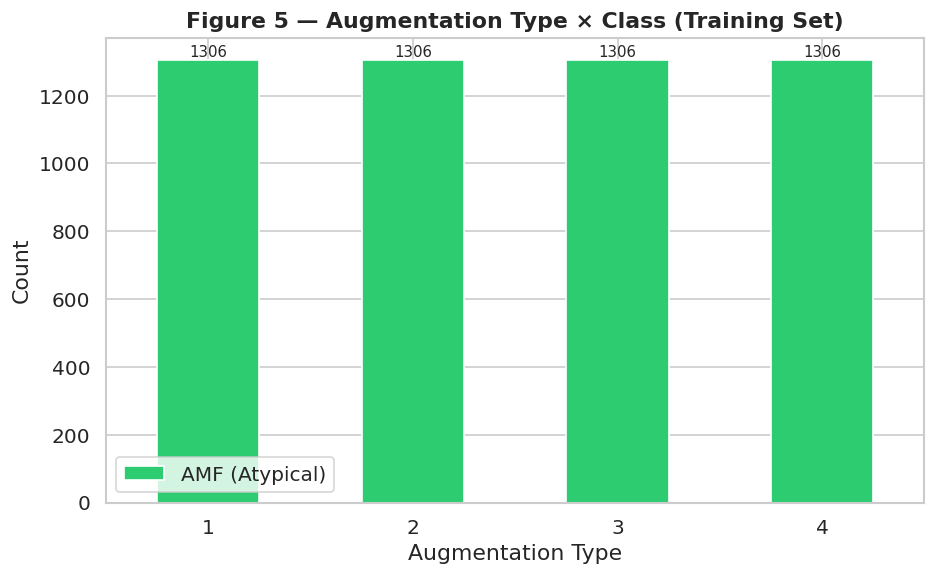

In [8]:
train_aug = df[(df["split"] == "training") & (df["is_augmented"] == True)].copy()
train_aug["augmentation_type"] = train_aug["augmentation_type"].astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
ct_aug = pd.crosstab(train_aug["augmentation_type"], train_aug["label"])
ct_aug.plot.bar(ax=ax, color=[COLORS["NMF (Normal)"], COLORS["AMF (Atypical)"]],
                edgecolor="white", rot=0)
annotate_bars(ax)
ax.set_xlabel("Augmentation Type")
ax.set_ylabel("Count")
ax.set_title("Figure 5 — Augmentation Type × Class (Training Set)", fontweight="bold")
ax.legend(title="")
plt.tight_layout()
plt.show()

## Sample Images (NMF vs AMF)

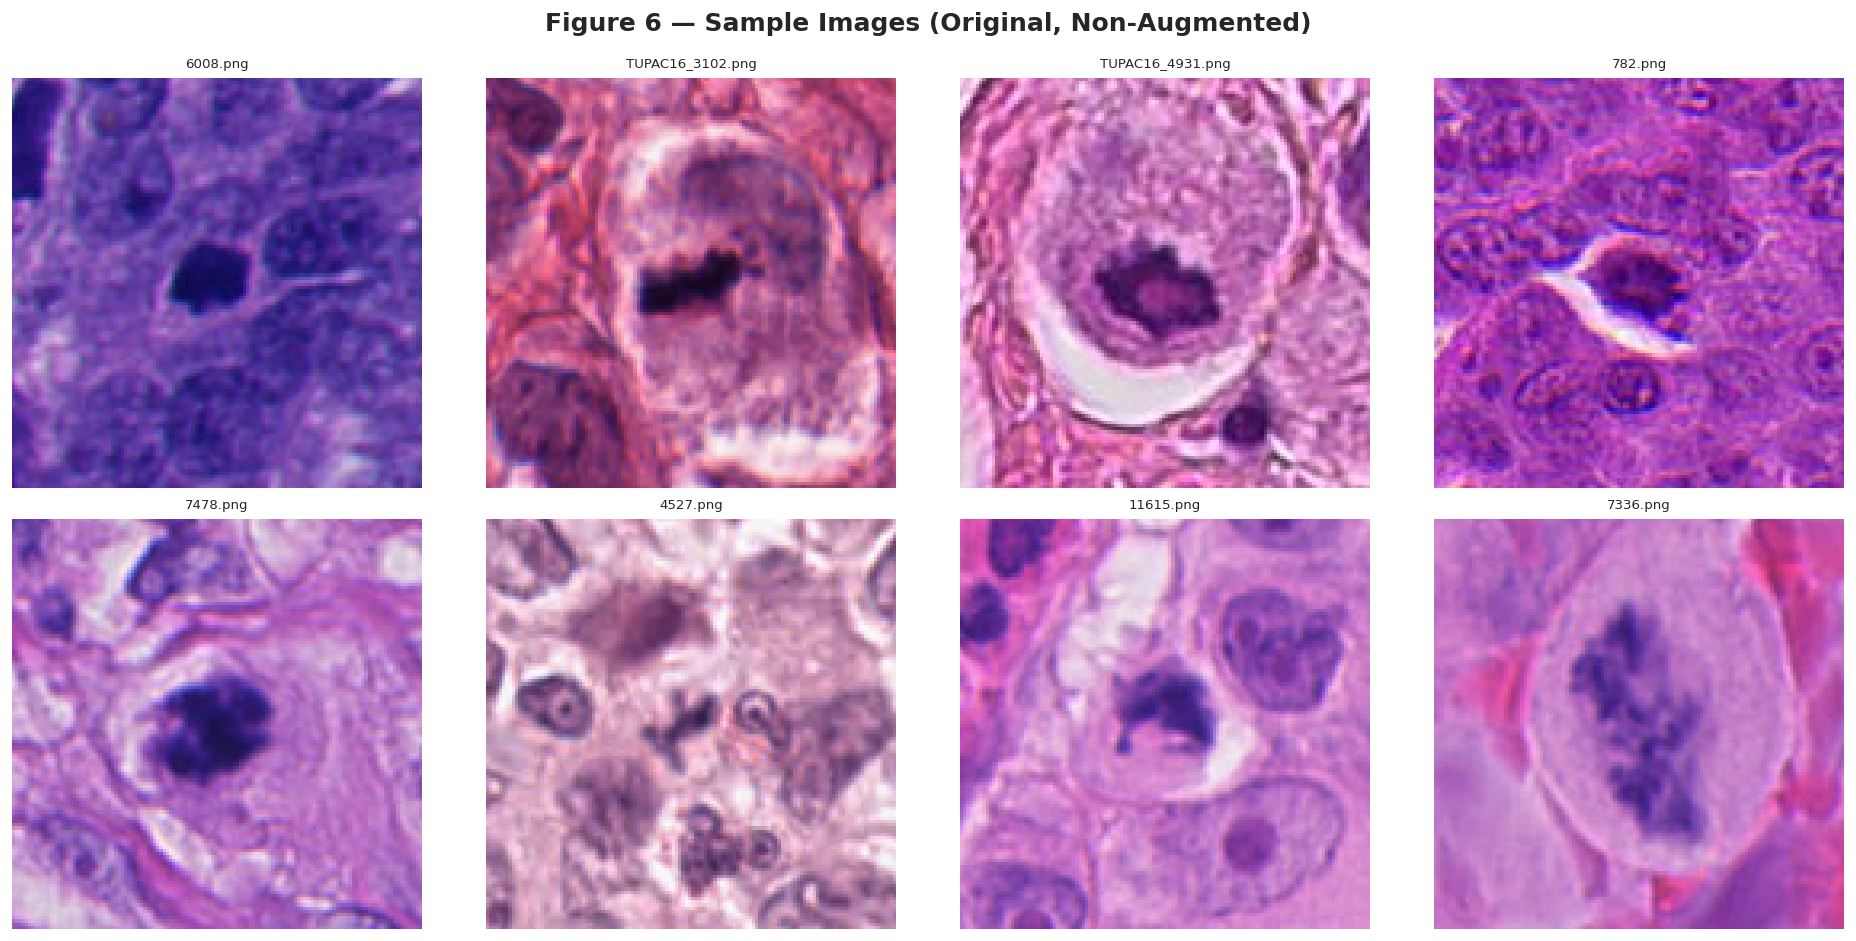

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row_idx, (lbl, grp_name) in enumerate(
    [(False, "NMF (Normal)"), (True, "AMF (Atypical)")]
):
    subset = df[(df["is_atypical"] == lbl) & (df["is_augmented"] == False)]
    samples = subset.sample(n=4, random_state=42)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_idx, col_idx]
        img_path = os.path.join(DATASET_PATH, row["split"], row["filename"])
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
        except FileNotFoundError:
            ax.text(0.5, 0.5, "Not found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(row["filename"], fontsize=8)
        ax.axis("off")
    axes[row_idx, 0].set_ylabel(grp_name, fontsize=13, fontweight="bold", rotation=90, labelpad=15)
    axes[row_idx, 0].yaxis.set_visible(True)
    axes[row_idx, 0].set_yticks([])

fig.suptitle("Figure 6 — Sample Images (Original, Non‑Augmented)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Augmentation Showcase

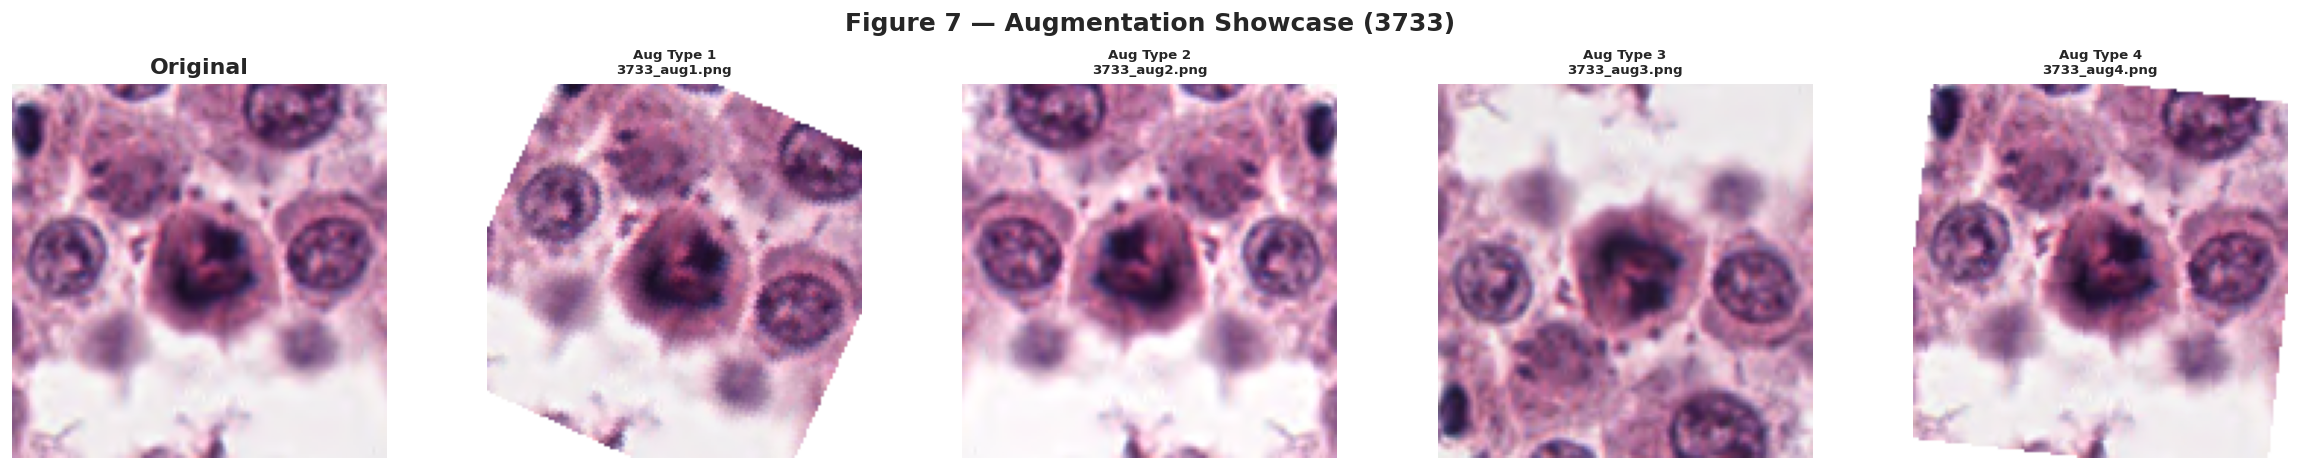

Base image: 3733.png
Augmented variants found: 4
     filename  augmentation_type
3733_aug1.png                1.0
3733_aug2.png                2.0
3733_aug3.png                3.0
3733_aug4.png                4.0


In [10]:
# Pick an original training image
train_orig = df[(df["split"] == "training") & (df["is_augmented"] == False)]
sample_row = train_orig.iloc[0]
sample_file = sample_row["filename"]
base_name = sample_file.replace(".png", "")

# Find its augmented variants from the CSV itself
aug_variants = df[
    (df["filename"].str.startswith(base_name + "_aug")) &
    (df["split"] == "training")
].sort_values("augmentation_type")

# If no variants found for first image, try another
if len(aug_variants) == 0:
    for _, row in train_orig.iterrows():
        base = row["filename"].replace(".png", "")
        aug_variants = df[
            (df["filename"].str.startswith(base + "_aug")) &
            (df["split"] == "training")
        ].sort_values("augmentation_type")
        if len(aug_variants) > 0:
            sample_file = row["filename"]
            base_name = base
            break

n_aug = len(aug_variants)
fig, axes = plt.subplots(1, 1 + n_aug, figsize=(4 * (1 + n_aug), 4))
if not isinstance(axes, np.ndarray):
    axes = [axes]

# Original
img_path = os.path.join(DATASET_PATH, "training", sample_file)
try:
    axes[0].imshow(mpimg.imread(img_path))
except FileNotFoundError:
    axes[0].text(0.5, 0.5, "Not found", ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

# Augmented variants
for i, (_, aug_row) in enumerate(aug_variants.iterrows()):
    aug_path = os.path.join(DATASET_PATH, "training", aug_row["filename"])
    try:
        axes[i + 1].imshow(mpimg.imread(aug_path))
    except FileNotFoundError:
        axes[i + 1].text(0.5, 0.5, "Not found", ha="center", va="center", transform=axes[i + 1].transAxes)
    aug_type = int(aug_row["augmentation_type"])
    axes[i + 1].set_title(f"Aug Type {aug_type}\n{aug_row['filename']}", fontweight="bold", fontsize=8)
    axes[i + 1].axis("off")

fig.suptitle(f"Figure 7 — Augmentation Showcase ({base_name})", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Debug: print what was found
print(f"Base image: {sample_file}")
print(f"Augmented variants found: {len(aug_variants)}")
print(aug_variants[["filename", "augmentation_type"]].to_string(index=False))

## Summary Table (EDA)

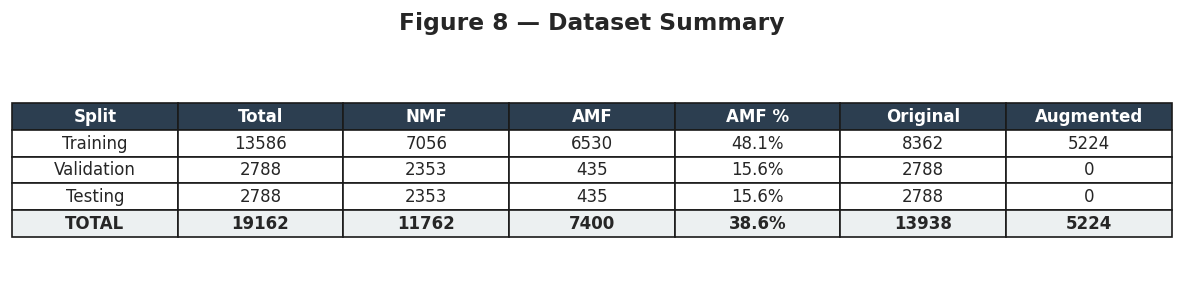

In [11]:
summary_data = []
for split in SPLIT_ORDER:
    s = df[df["split"] == split]
    summary_data.append({
        "Split": split.capitalize(),
        "Total": len(s),
        "NMF": (s["is_atypical"] == False).sum(),
        "AMF": (s["is_atypical"] == True).sum(),
        "AMF %": f"{(s['is_atypical'] == True).mean() * 100:.1f}%",
        "Original": (s["is_augmented"] == False).sum(),
        "Augmented": (s["is_augmented"] == True).sum(),
    })
summary_data.append({
    "Split": "TOTAL", "Total": len(df),
    "NMF": (df["is_atypical"] == False).sum(),
    "AMF": (df["is_atypical"] == True).sum(),
    "AMF %": f"{(df['is_atypical'] == True).mean() * 100:.1f}%",
    "Original": (df["is_augmented"] == False).sum(),
    "Augmented": (df["is_augmented"] == True).sum(),
})
summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")
table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                 loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
for j in range(len(summary_df.columns)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")
for j in range(len(summary_df.columns)):
    table[len(summary_data), j].set_facecolor("#ecf0f1")
    table[len(summary_data), j].set_text_props(fontweight="bold")

fig.suptitle("Figure 8 — Dataset Summary", fontsize=14, fontweight="bold", y=0.95)
plt.tight_layout()
plt.show()